In [845]:
from PIL import Image
import cv2
import matplotlib.pyplot as plt
import numpy as np

import pytesseract
import frr
from frr import FastReflectionRemoval

In [846]:
cv2.destroyAllWindows()

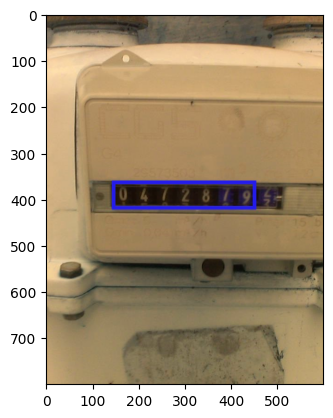

In [847]:
#image = cv2.imread('temp_dataset/annotation/00882400012471_0.jpg')
image = cv2.imread('temp_dataset/annotation/02800000313255_0.jpg')
plt.imshow(image)

In [848]:
imagedraw = cv2.selectROI(image)
#plt.imshow(imagedraw)
cv2.waitKey(0)

Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!


13

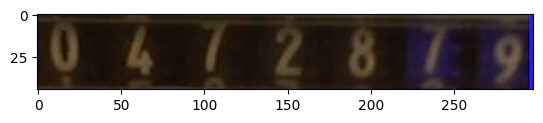

In [ ]:
croppedimage = image[int(imagedraw[1]):int(imagedraw[1]+imagedraw[3]), int(imagedraw[0]):int(imagedraw[0]+imagedraw[2])]
plt.imshow(croppedimage)

Try removing the reflection (doesn't work the best)

In [850]:
# model = FastReflectionRemoval(h=0.033)
# croppedimage = croppedimage.astype('float32') / 255.0

# npdata = np.asarray(img)
# alg = FastReflectionRemoval(h=0.11)
#new_img = alg.remove_reflection(img)
#output = model.remove_reflection(croppedimage)
# cv2.imwrite('output_img.jpg', output*255.0)

# less_reflection_img = cv2.imread('output_img.jpg')

Sharpening makes the image look a little worse

In [851]:
# sharp = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
# image_sharp = cv2.filter2D(src=croppedimage, ddepth=-1, kernel=sharp)

# plt.imshow(image_sharp)

In [852]:
# lower = (0, 0, 0)
# upper = (240, 240, 240)
# thresh = cv2.inRange(croppedimage, lower, upper)

# kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7,7))
# morph = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=1)
# kernel = cv2.getStructuringElement(cv2.MORPH_TECT, (25,25))
# morph = cv2.morphologyEx(morph, cv2.MORPH_DILATE, kernel, iterations=1)
# plt.imshow(morph)

In [853]:
# #hsv = cv2.cvtColor(less_reflection_img, cv2.COLOR_BGR2HSV)
# hsv = cv2.cvtColor(croppedimage, cv2.COLOR_BGR2HSV)
# plt.imshow(hsv)

In [854]:
gray = cv2.cvtColor(croppedimage, cv2.COLOR_BGR2GRAY)
# plt.imshow(gray)

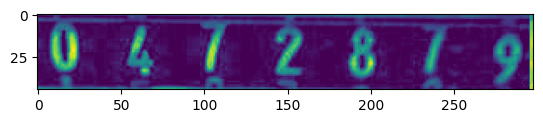

In [855]:
lower_black = np.array([0, 0, 0])
upper_black = np.array([350, 155, 100])
image_mask = cv2.inRange(croppedimage, lower_black, upper_black)
#plt.imshow(image_mask))
rectKernel = cv2.getStructuringElement(cv2.MORPH_RECT, (13,7))
tophat = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, rectKernel)
plt.imshow(tophat)
data = pytesseract.image_to_string(tophat, lang='eng', config='--psm 10 --oem 3 -c tessedit_char_whitelist=0123456789')
print(data)

In [856]:

# hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
# # pytesseract.pytesseract.tesseract_cmd = 
# gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# blur = cv2.GaussianBlur(gray, (3,3), 0)
# thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]

# kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
# opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
# invert = 255 - opening
# plt.imshow(invert)
# data = pytesseract.image_to_string(invert, lang='eng', config='--psm 10 --oem 3')
# print(data)

# # cv2.imshow('thresh', thresh)
# # cv2.imshow('opening', opening)
# # cv2.imshow('invert', invert)

In [857]:
#gray = cv2.cvtColor(croppedimage, cv2.COLOR_BGR2GRAY)

ret, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

kernel = np.ones((3,3), np.uint8)
eroded = cv2.erode(binary, kernel, iterations=1)
cv2.imshow('eroded', eroded)

dilated = cv2.dilate(eroded, kernel, iterations=1)
# cv2.imshow('dilated', dilated)


In [858]:
contours, hierarchy = cv2.findContours(tophat, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    cv2.rectangle(croppedimage, (x, y), (x+w, y+h), (0, 255, 0), 2)
    digits = gray[y:y+h, x:x+w]

# cv2.imshow('output', image)
plt.imshow(image)
cv2.destroyAllWindows()